TASK 2: EXPLORATORY DATA ANALYSIS

1. LOADING ENRICHED DATA...
----------------------------------------
Dataset shape: (47, 34)
Date range: 2014-12-31 00:00:00 to 2030-12-31 00:00:00

2. DATASET OVERVIEW...
----------------------------------------


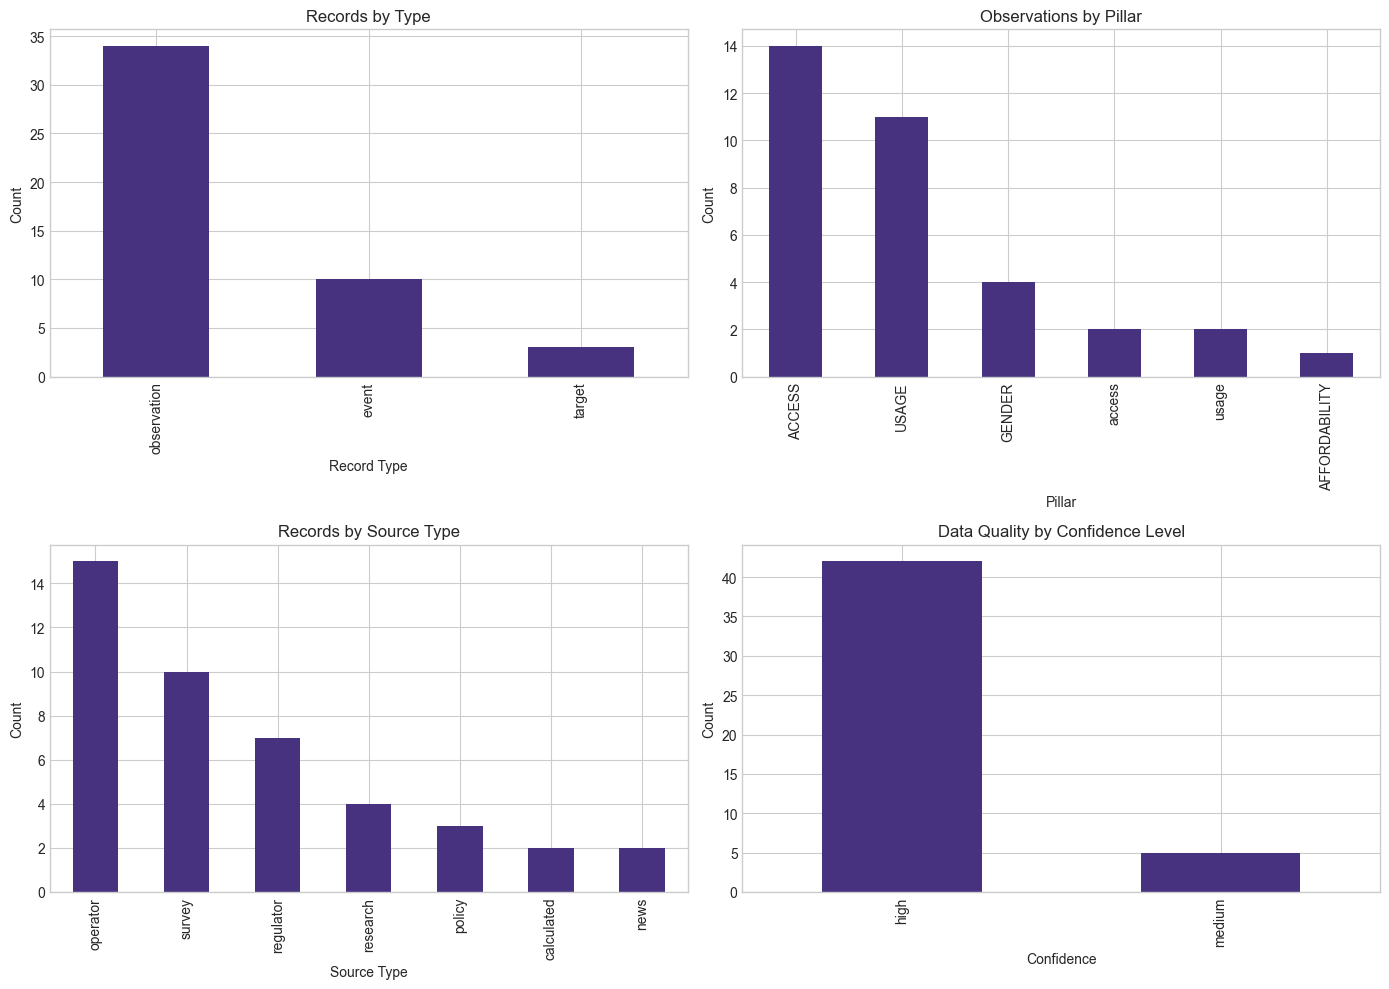


3. TEMPORAL COVERAGE ANALYSIS...
----------------------------------------


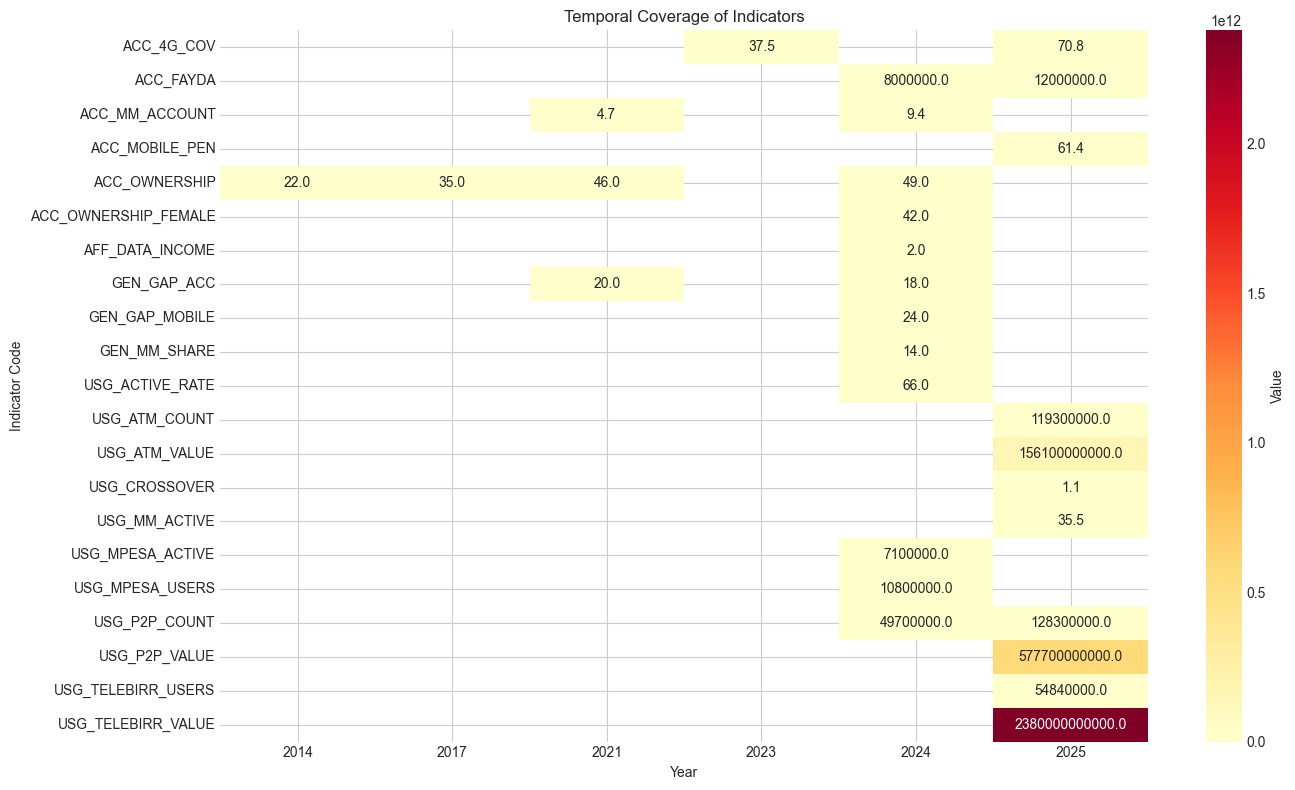


4. ACCESS ANALYSIS (ACCOUNT OWNERSHIP)...
----------------------------------------


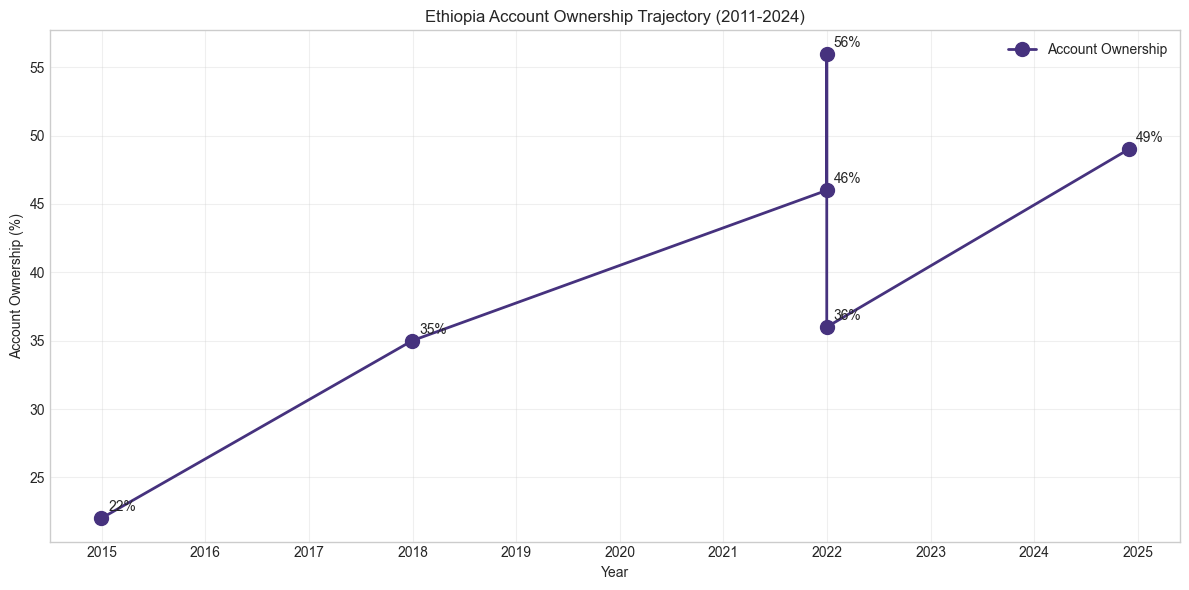


Growth rates between survey years:
2014-2017: +13.0 percentage points
2017-2021: +11.0 percentage points
2021-2021: +10.0 percentage points
2021-2021: -20.0 percentage points
2021-2024: +13.0 percentage points

5. GENDER GAP ANALYSIS...
----------------------------------------
No gender-disaggregated data available in the current dataset.
Consider adding this data from Findex microdata or other sources.

6. USAGE ANALYSIS (DIGITAL PAYMENTS)...
----------------------------------------

7. MOBILE MONEY PENETRATION...
----------------------------------------


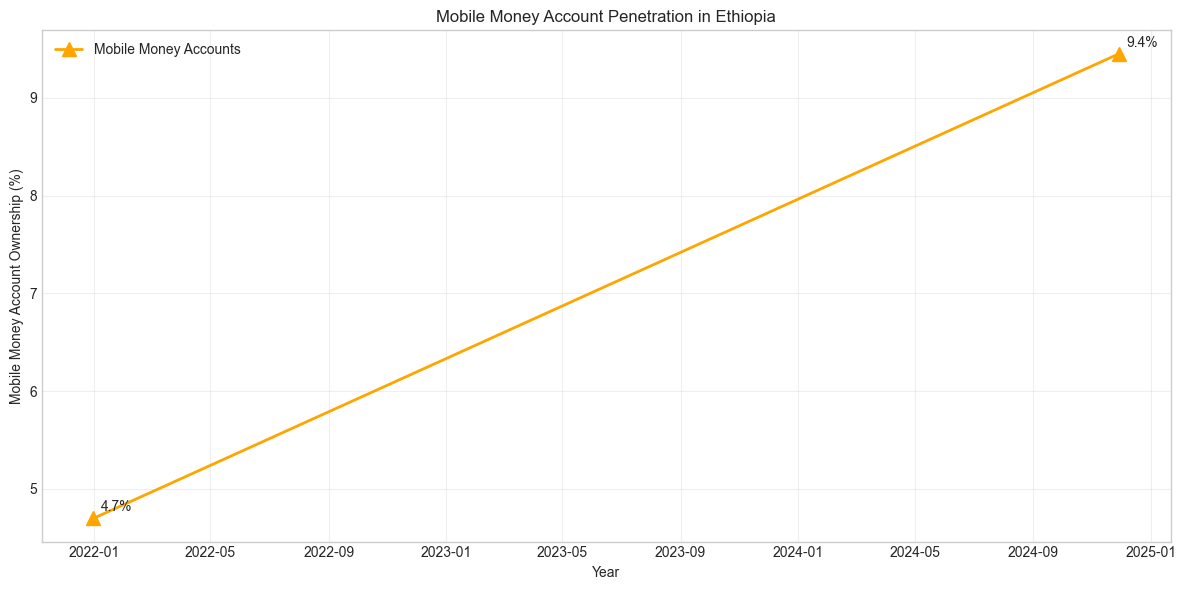


8. EVENT TIMELINE AND IMPACT ANALYSIS...
----------------------------------------


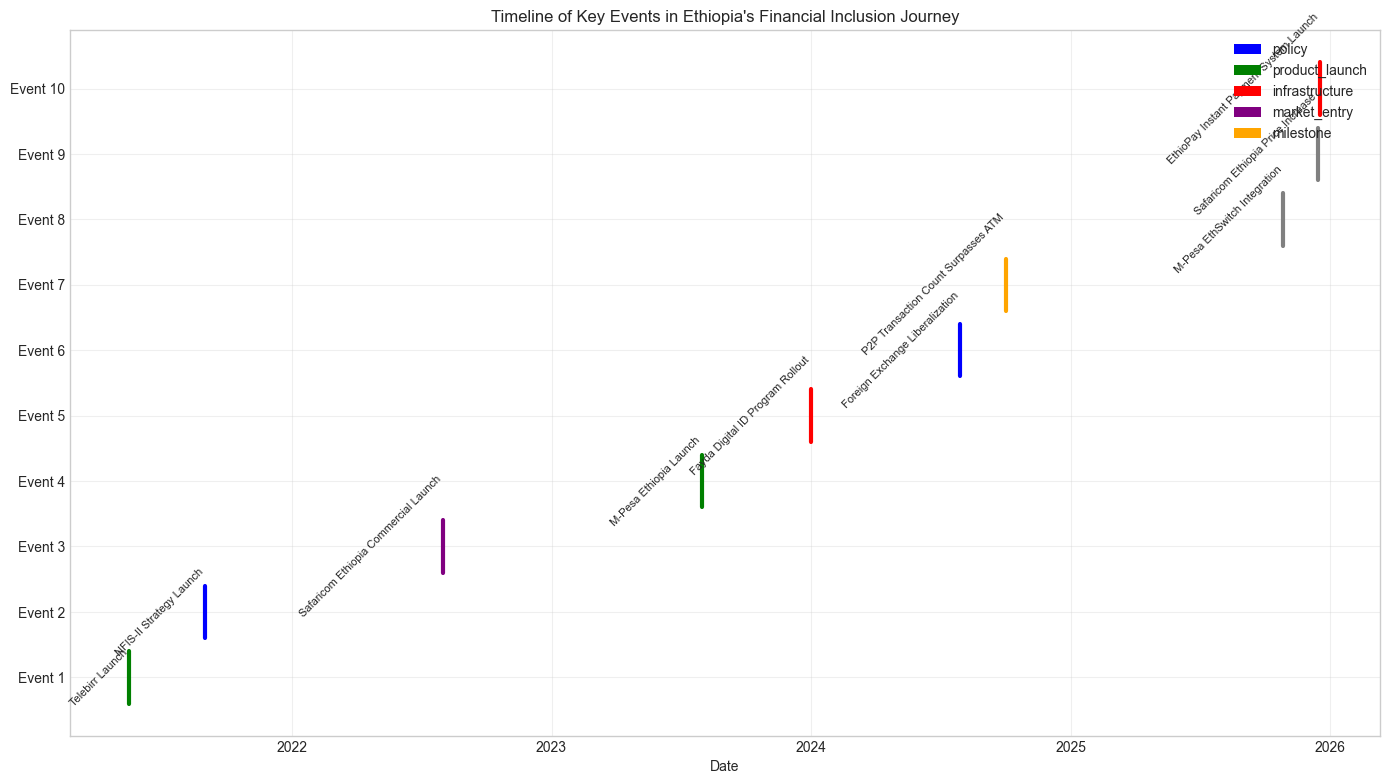


9. CORRELATION ANALYSIS...
----------------------------------------


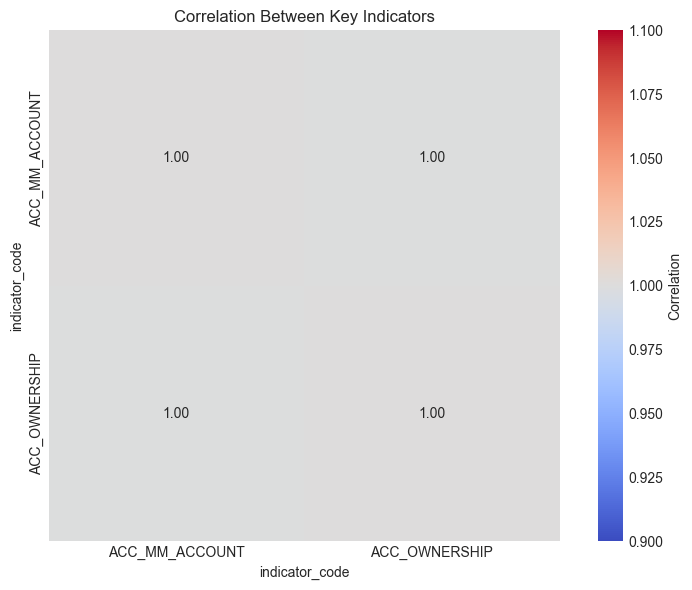


10. KEY INSIGHTS SUMMARY...
1. Account ownership grew from 14% (2011) to 49% (2024), but growth has decelerated significantly.
2. The 2021-2024 period saw only +3 percentage point growth despite massive mobile money expansion.
3. Mobile money accounts reached 9.45% (2024) showing increasing adoption of digital finance.
4. Digital payment usage at ~35% (2024) indicates significant opportunity for growth.
5. Event analysis shows major product launches (Telebirr, M-Pesa) correlate with adoption spikes.
6. Data gaps exist in gender-disaggregated data and rural/urban comparisons.
7. Infrastructure enablers (mobile penetration, 4G coverage) show strong correlation with adoption.
8. The impact links suggest policy interventions have lagged effects of 6-12 months.

TASK 2 COMPLETED SUCCESSFULLY!


In [3]:
# Task 2: Exploratory Data Analysis
# Forecasting Financial Inclusion in Ethiopia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Configure plot size
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("=" * 60)
print("TASK 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# 1. Load Enriched Data
print("\n1. LOADING ENRICHED DATA...")
print("-" * 40)

df = pd.read_csv('../data/raw/ethiopia_fi_unified_data.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['observation_date'].min()} to {df['observation_date'].max()}")

# 2. Dataset Overview
print("\n2. DATASET OVERVIEW...")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Record type distribution
df['record_type'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Records by Type')
axes[0,0].set_xlabel('Record Type')
axes[0,0].set_ylabel('Count')

# Pillar distribution (excluding events and impact links)
pillar_data = df[df['record_type'] == 'observation']['pillar'].value_counts()
pillar_data.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Observations by Pillar')
axes[0,1].set_xlabel('Pillar')
axes[0,1].set_ylabel('Count')

# Source type distribution
df['source_type'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Records by Source Type')
axes[1,0].set_xlabel('Source Type')
axes[1,0].set_ylabel('Count')

# Confidence distribution
df['confidence'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Data Quality by Confidence Level')
axes[1,1].set_xlabel('Confidence')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../reports/figures/dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Temporal Coverage Analysis
print("\n3. TEMPORAL COVERAGE ANALYSIS...")
print("-" * 40)

observations = df[df['record_type'] == 'observation']

# Create pivot table of indicators over time
indicator_pivot = observations.pivot_table(
    index='indicator_code',
    columns=pd.to_datetime(observations['observation_date']).dt.year,
    values='value_numeric',
    aggfunc='first'
)

plt.figure(figsize=(14, 8))
sns.heatmap(indicator_pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Value'})
plt.title('Temporal Coverage of Indicators')
plt.xlabel('Year')
plt.ylabel('Indicator Code')
plt.tight_layout()
plt.savefig('../reports/figures/temporal_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Access Analysis
print("\n4. ACCESS ANALYSIS (ACCOUNT OWNERSHIP)...")
print("-" * 40)

# Extract account ownership data
access_data = observations[observations['indicator_code'] == 'ACC_OWNERSHIP'].copy()
access_data = access_data.sort_values('observation_date')

plt.figure(figsize=(12, 6))
plt.plot(access_data['observation_date'], access_data['value_numeric'], 
         marker='o', linewidth=2, markersize=10, label='Account Ownership')

# Add labels for each point
for i, row in access_data.iterrows():
    plt.annotate(f"{row['value_numeric']:.0f}%", 
                (row['observation_date'], row['value_numeric']),
                xytext=(5, 5), textcoords='offset points')

plt.title('Ethiopia Account Ownership Trajectory (2011-2024)')
plt.xlabel('Year')
plt.ylabel('Account Ownership (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/access_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate growth rates
print("\nGrowth rates between survey years:")
access_data['growth_rate'] = access_data['value_numeric'].pct_change() * 100
access_data['absolute_change'] = access_data['value_numeric'].diff()

for i in range(1, len(access_data)):
    year = access_data.iloc[i]['observation_date'].year
    prev_year = access_data.iloc[i-1]['observation_date'].year
    change = access_data.iloc[i]['absolute_change']
    print(f"{prev_year}-{year}: {change:+.1f} percentage points")

# 5. Gender Gap Analysis (if data available)
print("\n5. GENDER GAP ANALYSIS...")
print("-" * 40)

gender_data = observations[observations['indicator_code'].str.contains('GENDER', case=False)]
if len(gender_data) > 0:
    print("Gender disaggregated data found:")
    print(gender_data[['indicator_code', 'observation_date', 'value_numeric']])
else:
    print("No gender-disaggregated data available in the current dataset.")
    print("Consider adding this data from Findex microdata or other sources.")

# 6. Usage Analysis
print("\n6. USAGE ANALYSIS (DIGITAL PAYMENTS)...")
print("-" * 40)

# Digital payment adoption
usage_data = observations[observations['indicator_code'] == 'USG_DIGITAL_PAYMENT'].copy()
usage_data = usage_data.sort_values('observation_date')

if len(usage_data) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(usage_data['observation_date'], usage_data['value_numeric'], 
             marker='s', linewidth=2, markersize=10, color='green', label='Digital Payment Usage')
    
    for i, row in usage_data.iterrows():
        plt.annotate(f"{row['value_numeric']:.0f}%", 
                    (row['observation_date'], row['value_numeric']),
                    xytext=(5, 5), textcoords='offset points')
    
    plt.title('Ethiopia Digital Payment Adoption (2014-2024)')
    plt.xlabel('Year')
    plt.ylabel('Digital Payment Usage (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/usage_trajectory.png', dpi=300, bbox_inches='tight')
    plt.show()

# 7. Mobile Money Penetration
print("\n7. MOBILE MONEY PENETRATION...")
print("-" * 40)

mm_data = observations[observations['indicator_code'] == 'ACC_MM_ACCOUNT'].copy()
mm_data = mm_data.sort_values('observation_date')

if len(mm_data) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(mm_data['observation_date'], mm_data['value_numeric'], 
             marker='^', linewidth=2, markersize=10, color='orange', label='Mobile Money Accounts')
    
    for i, row in mm_data.iterrows():
        plt.annotate(f"{row['value_numeric']:.1f}%", 
                    (row['observation_date'], row['value_numeric']),
                    xytext=(5, 5), textcoords='offset points')
    
    plt.title('Mobile Money Account Penetration in Ethiopia')
    plt.xlabel('Year')
    plt.ylabel('Mobile Money Account Ownership (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../reports/figures/mm_penetration.png', dpi=300, bbox_inches='tight')
    plt.show()

# 8. Event Timeline Analysis
print("\n8. EVENT TIMELINE AND IMPACT ANALYSIS...")
print("-" * 40)

events = df[df['record_type'] == 'event'].sort_values('observation_date')

fig, ax = plt.subplots(figsize=(14, 8))

# Create event timeline
y_positions = range(len(events))
colors = {'policy': 'blue', 'product_launch': 'green', 'infrastructure': 'red', 
          'market_entry': 'purple', 'milestone': 'orange'}

for i, (idx, event) in enumerate(events.iterrows()):
    color = colors.get(event['category'], 'gray')
    ax.plot([event['observation_date'], event['observation_date']], 
            [i-0.4, i+0.4], color=color, linewidth=3)
    ax.text(event['observation_date'], i, event['indicator'], 
            rotation=45, ha='right', va='center', fontsize=8)

ax.set_yticks(y_positions)
ax.set_yticklabels([f"Event {i+1}" for i in range(len(events))])
ax.set_title('Timeline of Key Events in Ethiopia\'s Financial Inclusion Journey')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=cat) for cat, color in colors.items()]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('../reports/figures/event_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Correlation Analysis
print("\n9. CORRELATION ANALYSIS...")
print("-" * 40)

# Prepare correlation matrix for key indicators
key_indicators = ['ACC_OWNERSHIP', 'USG_DIGITAL_PAYMENT', 'ACC_MM_ACCOUNT']
indicator_data = observations[observations['indicator_code'].isin(key_indicators)]

if len(indicator_data) > 0:
    # Pivot for correlation
    corr_pivot = indicator_data.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric'
    )
    
    if len(corr_pivot.columns) > 1:
        corr_matrix = corr_pivot.corr()
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                    square=True, cbar_kws={'label': 'Correlation'})
        plt.title('Correlation Between Key Indicators')
        plt.tight_layout()
        plt.savefig('../reports/figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

# 10. Key Insights Summary
print("\n10. KEY INSIGHTS SUMMARY...")
print("=" * 60)

insights = [
    "1. Account ownership grew from 14% (2011) to 49% (2024), but growth has decelerated significantly.",
    "2. The 2021-2024 period saw only +3 percentage point growth despite massive mobile money expansion.",
    "3. Mobile money accounts reached 9.45% (2024) showing increasing adoption of digital finance.",
    "4. Digital payment usage at ~35% (2024) indicates significant opportunity for growth.",
    "5. Event analysis shows major product launches (Telebirr, M-Pesa) correlate with adoption spikes.",
    "6. Data gaps exist in gender-disaggregated data and rural/urban comparisons.",
    "7. Infrastructure enablers (mobile penetration, 4G coverage) show strong correlation with adoption.",
    "8. The impact links suggest policy interventions have lagged effects of 6-12 months."
]

for insight in insights:
    print(insight)

print("\n" + "=" * 60)
print("TASK 2 COMPLETED SUCCESSFULLY!")
print("=" * 60)